In [1]:
from collections import OrderedDict
import matplotlib.pyplot as plt
import numpy as np
import scipy
import torch
from torch.func import functional_call, grad, vjp, vmap
import torchopt

# Differential equation

The differential equation to solve is:
$$
    \frac{d^2 \theta}{dt^2} = -\frac{g}{l} \sin \theta - q \frac{d \theta}{dt}
$$
with initial condition $\theta(0) = \theta_0$ and $\frac{d \theta}{dt} = 0$. Futhermore, we choose \frac{g}{l} = 1$, so the only parameter is $q$.

This equation models a pendulum subject to gravity and friction.

In [2]:
t_0, θ_0, ω_0 = 0.0, 0.2, 0.0
initial_values = t_0, θ_0, ω_0
q = 0.1

In [3]:
def rhs(t, x, q):
    θ, ω = x
    return [
        ω,
        -np.sin(θ) - q*ω,
    ]

In [4]:
def jac(t, x, q):
    θ, ω = x
    return [
        [0.0, 1.0],
        [-np.cos(θ), -q]
    ]

In [5]:
ode = scipy.integrate.ode(rhs, jac) \
    .set_initial_value([θ_0, ω_0], t_0) \
    .set_integrator('dopri5') \
    .set_f_params(q) \
    .set_jac_params(q)

In [6]:
t_domain = t_0, 20.0
Δt = 0.01
t_values, θ_values = [ode.t], [ode.y[0]]
while ode.successful() and ode.t < t_domain[1]:
    ode.integrate(ode.t + 0.01)
    t_values.append(ode.t)
    θ_values.append(ode.y[0])

In [7]:
len(θ_values)

2001

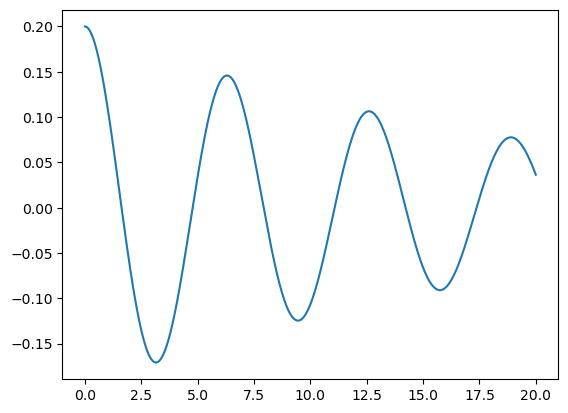

In [8]:
plt.plot(t_values, θ_values);

In [9]:
sample_indices = np.random.choice(len(θ_values), 100)
t_data = [t_values[i] for i in sample_indices]
θ_data = [θ_values[i] for i in sample_indices]

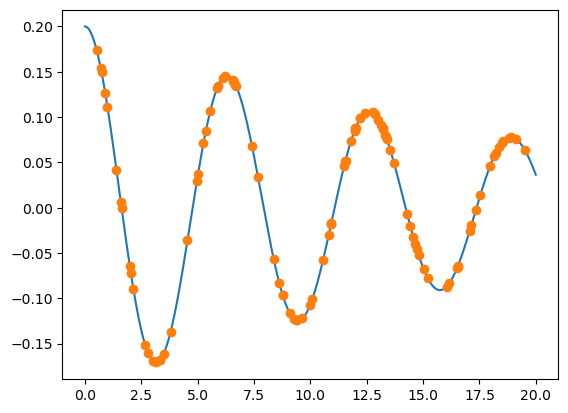

In [10]:
plt.plot(t_values, θ_values)
plt.plot(t_data, θ_data, 'o');

# Model

In [11]:
class PINN(torch.nn.Module):

    def __init__(self, nr_inputs, nr_layers, nr_neurons, activation=torch.nn.Tanh()):
        super().__init__()
        self.num_inputs = nr_inputs
        self.num_layers = nr_layers
        self.num_neurons = nr_neurons
        layers = []
        layers.append(torch.nn.Linear(self.num_inputs, self.num_neurons))
        layers.append(activation)
        for _ in range(self.num_layers):
            layers.append(torch.nn.Linear(self.num_neurons, self.num_neurons))
            layers.append(activation)
        layers.append(torch.nn.Linear(self.num_neurons, 1))
        self.network = torch.nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x.reshape(-1, 1)).squeeze()

In [12]:
nr_inputs, nr_neurons, nr_layers = 1, 20, 5

In [13]:
model = PINN(nr_inputs=nr_inputs, nr_neurons=nr_neurons, nr_layers=nr_layers)

Now we get the neural network's current parameters as a tuple.

In [14]:
params = tuple(model.parameters())

In [15]:
def tuple_to_dict_parameters(model, params):
    keys = list(dict(model.named_parameters()).keys())
    values = list(params)
    return OrderedDict(({k:v for k, v in zip(keys, values)}))

Now we can write a function that computes a function and its derivatives.

In [16]:
def make_forward_functions(model, derivative_order=1):

    def f(x, params):
        if isinstance(params, tuple):
            params_dict = tuple_to_dict_parameters(model, params)
        else:
            params_dict = params
        return functional_call(model, params_dict, (x, ), )

    fns = [f]
    for _ in range(derivative_order):
        dfunc = grad(fns[-1])
        fns.append(dfunc)
    return fns[:1] + [vmap(fn, in_dims=(0, None)) for fn in fns[1:]]

In [17]:
θ, dθdt, d2θdt2 = make_forward_functions(model, derivative_order=2)

Using these forward functions, you can write a function that will create the loss function.  The loss function consists of two parts: one part will enforce the initial conditions, the other the function values.

In [18]:
def make_loss_functions(θ, dθdt, d2θdt2, q, initial_values,
                        t_data, θ_data):
    t_0, θ_0, dθdt_0 = initial_values
    loss = torch.nn.MSELoss()
    
    def loss_function(params, t):
        function_values = d2θdt2(t, params) + θ(t, params) + q*dθdt(t, params)
        initial_condition_θ = θ(torch.Tensor([t_0]), params) - torch.Tensor([θ_0])
        initial_condition_dθdt = dθdt(torch.Tensor([t_0]), params) - torch.Tensor([dθdt_0])
        data_values = θ(t_data, params)
        return (loss(function_values, torch.zeros_like(function_values)) +
                loss(initial_condition_θ, torch.zeros_like(initial_condition_θ)) +
                loss(initial_condition_dθdt, torch.zeros_like(initial_condition_dθdt)) +
                loss(data_values, θ_data))
    return loss_function

In [19]:
loss_function = make_loss_functions(θ, dθdt, d2θdt2, q, initial_values,
                                    torch.Tensor(t_data),
                                    torch.Tensor(θ_data))

The Adam optimizer is used with a learning rate of 0.01.

In [20]:
learning_rate = 1.0e-2

In [21]:
optimizer = torchopt.FuncOptimizer(torchopt.adam(lr=learning_rate))

Now you can train the network.

In [22]:
batch_size = 50
nr_epochs = 2_000
loss_threshold = 1.0e-5

In [23]:
for epoch in range(nr_epochs):
    t = torch.FloatTensor(batch_size).uniform_(*t_domain)
    loss = loss_function(params, t)
    if loss < loss_threshold:
        break
    params = optimizer.step(loss, params)
    if epoch % 100 == 0:
        print(f'Epoch {epoch + 1} with loss {float(loss.detach()):.4e}')

Epoch 1 with loss 3.3539e-02
Epoch 101 with loss 6.6446e-03
Epoch 201 with loss 6.0668e-03
Epoch 301 with loss 5.7860e-03
Epoch 401 with loss 5.3355e-03
Epoch 501 with loss 5.0699e-03
Epoch 601 with loss 5.4226e-03
Epoch 701 with loss 4.1286e-03
Epoch 801 with loss 2.8586e-03
Epoch 901 with loss 1.9419e-03
Epoch 1001 with loss 1.8660e-03
Epoch 1101 with loss 1.1852e-03
Epoch 1201 with loss 1.6899e-03
Epoch 1301 with loss 2.8312e-04
Epoch 1401 with loss 2.7637e-04
Epoch 1501 with loss 1.4357e-04
Epoch 1601 with loss 3.1441e-05


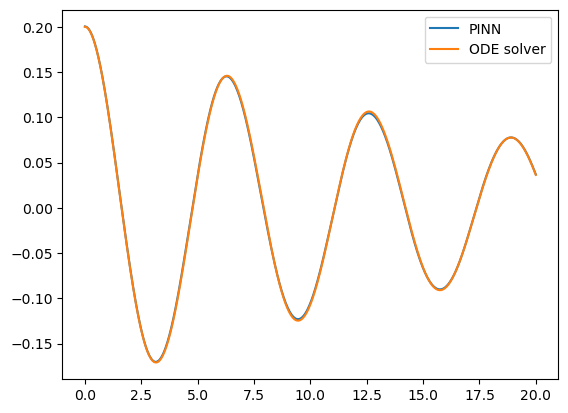

In [24]:
t_eval = torch.linspace(*t_domain, steps=1000).reshape(-1, 1)
values = θ(t_eval, params).detach().numpy()
plt.plot(t_eval.detach().numpy(), values, label='PINN')
plt.plot(t_values, θ_values, label='ODE solver')
plt.legend();

The PINN is doing a quite reasonable job.